In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib import colors

import argparse
import os
import uproot
import awkward as ak
from glob import glob

from boostedhh import utils

In [2]:
import xgboost as xgb

In [ ]:
os.listdir("/eos/uscms/store/user/lumori/bbtautau/trained_models") #/eos/uscms/store/user/lumori/bbtautau/trained_models

['10July25_baseline',
 '10July25_leptons',
 '13July25_leptons_noXbb',
 '20aug25_loweta_lowreg',
 '20aug25_loweta_lowreg_vbf',
 '28May25_baseline',
 '29July25_loweta_lowreg',
 'test',
 'test_2022']

In [4]:
MODEL_ROOT = Path("/eos/uscms/store/user/lumori/bbtautau/trained_models")
EXP_NAME = "10July25_baseline"
RUN_DIR    = (MODEL_ROOT / EXP_NAME).resolve()

assert RUN_DIR.exists(), f"Run dir not found: {RUN_DIR}"
print("RUN_DIR:", RUN_DIR)
print("FILES:", sorted([p.name for p in RUN_DIR.iterdir()]))

bst = xgb.Booster()
bst.load_model(str(RUN_DIR / "10July25_baseline.json"))

feat_names = getattr(bst, "feature_names", None)
print("Feature names:", feat_names)

RUN_DIR: /eos/uscms/store/user/lmori/bbtautau/trained_models/10July25_baseline
FILES: ['10July25_baseline.json', 'dtrain.buffer', 'dtrain_rescaled.buffer', 'dval.buffer', 'dval_rescaled.buffer', 'evals_result.json', 'feature_importance_gain.pdf', 'feature_importance_gain.png', 'feature_importance_total_gain.pdf', 'feature_importance_total_gain.png', 'feature_importance_weight.pdf', 'feature_importance_weight.png', 'outputs', 'rocs', 'scores', 'training_history.pdf', 'training_history.png', 'weight_stats.csv']
Feature names: ['METPt', 'METPhi', 'ttFatJetPt', 'ttFatJetPhi', 'ttFatJetEta', 'ttFatJetParTmassResApplied', 'ttFatJetParTmassVisApplied', 'ttFatJetParTQCD', 'ttFatJetParTTop', 'ttFatJetParTQCD0HF', 'ttFatJetParTQCD1HF', 'ttFatJetParTQCD2HF', 'ttFatJetParTTopW', 'ttFatJetParTTopbW', 'ttFatJetParTXtauhtauh', 'ttFatJetParTXtauhtaue', 'ttFatJetParTXtauhtaum', 'ttFatJetParTXbb']


In [ ]:
os.listdir("/eos/uscms/store/user/lumori/bbtautau/skimmer/")

['25Feb14Signal_v12_private_signal',
 '25Feb21Signal_v12_private_signal',
 '25Mar7Signal_v12_private_signal',
 '25Oct8_prescale0p001_v12_private_signal',
 '25Sep23AddVars_v12_private_signal']

In [ ]:
DATA_DIR = "/eos/uscms/store/user/lumori/bbtautau/skimmer/25Oct8_prescale0p001_v12_private_signal"
DATA_DIR_2022 = os.path.join(DATA_DIR, '2022')
# DATA_DIR_2022EE = os.path.join(DATA_DIR, '2022EE')
# DATA_DIR_2023 = os.path.join(DATA_DIR, '2023')
# DATA_DIR_2023BPix = os.path.join(DATA_DIR, '2023BPix')

display(os.listdir(DATA_DIR))
# display(os.listdir(DATA_DIR_2022)[:])
# display(os.listdir(DATA_DIR_2022EE))
# display(os.listdir(DATA_DIR_2023)[:15])
# display(os.listdir(DATA_DIR_2023BPix))

PARQUET_DIR = os.path.join(DATA_DIR_2022,  'GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00',"parquet")
display(os.listdir(PARQUET_DIR)[:10])

['2022', '2022EE', '2023', '2023BPix']

['out_0_batch_0.parquet', 'out_1_batch_0.parquet']

In [7]:
DATA_DIR = "/eos/uscms/store/user/lumori/bbtautau/skimmer/25Oct8_prescale0p001_v12_private_signal"
YEARS = ['2022', '2022EE', '2023', '2023BPix']
SAMPLE_NAME = "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00"
SUBDIR = "parquet"

all_parquet_paths = []

for year in YEARS:
    base = os.path.join(DATA_DIR, year, SAMPLE_NAME, SUBDIR)
    if os.path.exists(base):
        files = glob(os.path.join(base, "*.parquet"))
        all_parquet_paths.extend(files)
    else:
        print(f"⚠️ Skipped missing: {base}")

df = pd.concat([pd.read_parquet(fp) for fp in all_parquet_paths], ignore_index=True)
print(f"Loaded {len(df)} rows from {len(all_parquet_paths)} parquet files.")
df.head()

Loaded 996 rows from 16 parquet files.


GenHiggsEta           GenHiggsPhi           GenHiggsMass        GenHiggsPt  \
            0         1           0         1            0      1          0   
0   -1.050781 -2.085938    0.851562 -2.375000        125.0  125.0      232.5   
1    1.562500  0.235352    0.261719 -2.820312        125.0  125.0      274.0   
2    0.703125 -0.898438   -2.343750  0.722656        125.0  125.0      307.0   
3    0.527344 -0.531250   -1.312500  1.882812        125.0  125.0      312.0   
4    0.303711  0.724609   -2.695312  0.970703        125.0  125.0      298.0   

         GenHiggsChildren      ...    weight single_weight_genweight  \
       1                0   1  ...         0                       0   
0  260.0               15   5  ...  0.994185                 0.65807   
1  331.0                5  15  ...  0.170067                 0.65807   
2  290.0               15   5  ...  0.400307                 0.65807   
3  322.0               15   5  ...  0.741031                 0.65807   
4  342.0               15   5  ...  0.163990                 0.65807   

  single_weight_pileup single_weight_ISRPartonShower  \
                     0                             0   
0            30.018210                     19.869631   
1             5.134954                     19.869631   
2            12.086789                     19.869631   
3            22.374524                     19.869631   
4             4.951475                     19.869631   

  single_weight_FSRPartonShower weight_noxsec  \
                              0             0   
0                     19.869631      0.050035   
1                     19.869631      0.008559   
2                     19.869631      0.020147   
3                     19.869631      0.037295   
4                     19.869631      0.008253   

  HLT_AK8PFJet230_SoftDropMass40_PNetBB0p06  \
                                          0   
0                                       NaN   
1                                       NaN   
2                                       NaN   
3                                       NaN   
4                                       NaN   

  HLT_AK8PFJet230_SoftDropMass40_PNetTauTau0p03  \
                                              0   
0                                           NaN   
1                                           NaN   
2                                           NaN   
3                                           NaN   
4                                           NaN   

  HLT_PFHT340_QuadPFJet70_50_40_40_PNet2BTagMean0p70  \
                                                   0   
0                                                NaN   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4                                                NaN   

  HLT_PFHT280_QuadPFJet30_PNet2BTagMean0p55  
                                          0  
0                                       NaN  
1                                       NaN  
2                                       NaN  
3                                       NaN  
4                                       NaN  

[5 rows x 407 columns]

In [ ]:
df.weight.max()

0    5.808963
dtype: float64

In [ ]:
df.weight.min()

0   -4.411557
dtype: float64

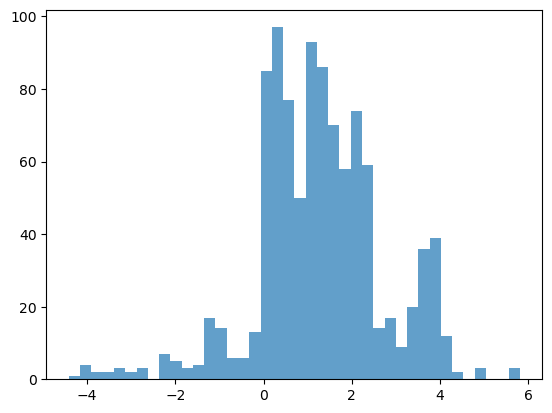

In [10]:
plt.hist(df.weight, bins=40, histtype='stepfilled', alpha=0.7)

plt.show()

In [ ]:
# df = pd.read_parquet(PARQUET_DIR)
# df.head()

In [ ]:
jet_indices = sorted({j for (name, j) in df.columns if name == 'ak8FatJetPt'})
print("Found jet indices:", jet_indices)

Found jet indices: [0, 1, 2]


In [ ]:
# build ττ-like jet (argmax of sum of τ-decay ParT scores)
tau_like = []
for j in jet_indices:
    tau_like.append(
        df[('ak8FatJetParTXtauhtauh', j)].to_numpy(np.float32, copy=False) +
        df[('ak8FatJetParTXtauhtaue', j)].to_numpy(np.float32, copy=False) +
        df[('ak8FatJetParTXtauhtaum', j)].to_numpy(np.float32, copy=False)
    )
tau_like = np.column_stack(tau_like)
taujet_pos = np.argmax(tau_like, axis=1)                         # position within jet_indices
taujet_idx = np.array([jet_indices[k] for k in taujet_pos], dtype=np.int32)

print("Tau jet indices:", taujet_idx)

# build bb-like jet (argmax of ParT Xbb)
xbb_mat = []
for j in jet_indices:
    xbb_mat.append(df[('ak8FatJetParTXbb', j)].to_numpy(np.float32, copy=False))
xbb_mat = np.column_stack(xbb_mat)
bb_pos1 = np.argmax(xbb_mat, axis=1)
bb_idx1 = np.array([jet_indices[k] for k in bb_pos1], dtype=np.int32)

# If the same jet is both τ and bb, take the second-best Xbb for bb-jet (when available)
order = np.argsort(xbb_mat, axis=1)  # ascending
second_best_pos = order[:, -2] if xbb_mat.shape[1] >= 2 else bb_pos1
bb_idx = bb_idx1.copy()
same = (bb_idx1 == taujet_idx)
bb_idx[same] = np.array([jet_indices[p] for p in second_best_pos[same]], dtype=np.int32)

print("BB jet indices:", bb_idx)

print("Number of events with same jet for ττ and bb:", np.sum(bb_idx == taujet_idx))

Tau jet indices: [0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0
 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 1 1 0 1 0 1 0 1 1 2 0 0 1 0 1 0
 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1
 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1
 1 0 0 1 1 0 1 0 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 2 0 1 0 1 0 0 1 0 0 0 1 1 0
 1 0 0 0 0 1 0 1 1 1 1 1 0 0 0 0 1 1 0 1 2 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1
 1 0 0 2 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 1 0 1 1 0 2 1 0 0 0 1 0 1 1 0 1
 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 0 1 0 2 0 0 1 0 0 1 0 0 1 1 0 1 1 1 0 0 1 0
 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 2 0 0 0 0
 0 1 0 0 1 1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 2 0 0 0 0 0 0 0 1 1 0 0
 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0
 0 0 0 0 1 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1
 1 1 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0 2 0 1 1 0 0 0 1 0 0
 0 1 0 0

In [14]:
# Add BDT scores to df

def gather(df, base, taujet_idx, dtype=np.float32):
    N = len(df)
    out = np.zeros(N, dtype=dtype)
    for i in range(N):
        key = (base, int(taujet_idx[i]))
        out[i] = df[key].iloc[i] if key in df.columns else 0.0
    return out

METPt  = df[('METPt', 0)].to_numpy(np.float32, copy=False)
METPhi = df[('METPhi', 0)].to_numpy(np.float32, copy=False)

ttFatJetPt  = gather(df, 'ak8FatJetPt', taujet_idx)
ttFatJetPhi = gather(df, 'ak8FatJetPhi', taujet_idx)
ttFatJetEta = gather(df, 'ak8FatJetEta', taujet_idx)

# ParT masses
tt_mRes = gather(df, 'ak8FatJetParTmassResApplied', taujet_idx)
tt_mVis = gather(df, 'ak8FatJetParTmassVisApplied', taujet_idx)

# QCD / Top components
qcd0  = gather(df, 'ak8FatJetParTQCD0HF', taujet_idx)
qcd1  = gather(df, 'ak8FatJetParTQCD1HF', taujet_idx)
qcd2  = gather(df, 'ak8FatJetParTQCD2HF', taujet_idx)
topW  = gather(df, 'ak8FatJetParTTopW', taujet_idx)
topbW = gather(df, 'ak8FatJetParTTopbW', taujet_idx)

# Sums required by the model
tt_qcd = (qcd0 + qcd1 + qcd2).astype(np.float32)
tt_top = (topW + topbW).astype(np.float32)

# ττ and Xbb ParT outputs
tx_hh  = gather(df, 'ak8FatJetParTXtauhtauh', taujet_idx)
tx_he  = gather(df, 'ak8FatJetParTXtauhtaue', taujet_idx)
tx_hm  = gather(df, 'ak8FatJetParTXtauhtaum', taujet_idx)
tx_xbb = gather(df, 'ak8FatJetParTXbb', taujet_idx)

df_bdt = pd.DataFrame({
    'METPt': METPt,
    'METPhi': METPhi,
    'ttFatJetPt': ttFatJetPt,
    'ttFatJetPhi': ttFatJetPhi,
    'ttFatJetEta': ttFatJetEta,
    'ttFatJetParTmassResApplied': tt_mRes,
    'ttFatJetParTmassVisApplied': tt_mVis,
    'ttFatJetParTQCD': tt_qcd,
    'ttFatJetParTTop': tt_top,
    'ttFatJetParTQCD0HF': qcd0,
    'ttFatJetParTQCD1HF': qcd1,
    'ttFatJetParTQCD2HF': qcd2,
    'ttFatJetParTTopW': topW,
    'ttFatJetParTTopbW': topbW,
    'ttFatJetParTXtauhtauh': tx_hh,
    'ttFatJetParTXtauhtaue': tx_he,
    'ttFatJetParTXtauhtaum': tx_hm,
    'ttFatJetParTXbb': tx_xbb,
}, columns=feat_names).astype(np.float32)

print("df_bdt.shape:", df_bdt.shape)

yhat = bst.inplace_predict(df_bdt)
print(yhat.shape)

# yhat is (nEvents, nClasses)
n_classes = yhat.shape[1]

for cls_idx in range(n_classes):
    df[("bdt_score", cls_idx)] = yhat[:, cls_idx].astype(np.float32)

df[("bdt_best_score", 0)] = np.max(yhat, axis=1).astype(np.float32)
df[("bdt_best_class", 0)] = np.argmax(yhat, axis=1).astype(np.int32)


df_bdt.shape: (996, 18)
(996, 8)


Predicted   0    1   2    4  5
True                          
GenTauhe   54   67  15   90  1
GenTauhh   15  242  13  159  0
GenTauhm   12   31  74   93  0


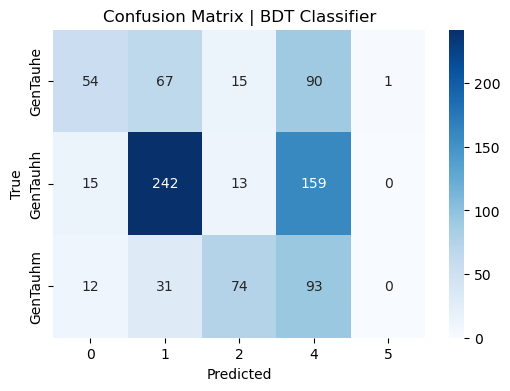

In [15]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Signal_Reg = ["GenTauhh", "GenTauhm", "GenTauhe"]

# Build a mapping from GenTauX flag to true label
true_labels = []
pred_labels = []

for sig in Signal_Reg:
    mask = df[(sig, 0)] == True
    filtered_values = df.loc[mask, ("bdt_best_class", 0)]
    
    true_labels.extend([sig] * len(filtered_values))
    pred_labels.extend(filtered_values.values)

# Create a labeled DataFrame
conf_df = pd.DataFrame({"True": true_labels, "Pred": pred_labels})

# Compute confusion matrix
cm = pd.crosstab(conf_df["True"], conf_df["Pred"], rownames=["True"], colnames=["Predicted"], normalize=False)
print(cm)


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix | BDT Classifier")
plt.show()

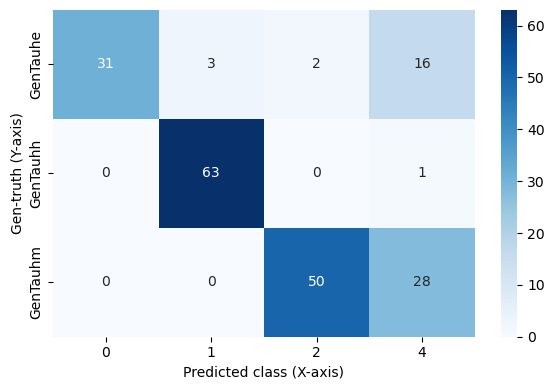

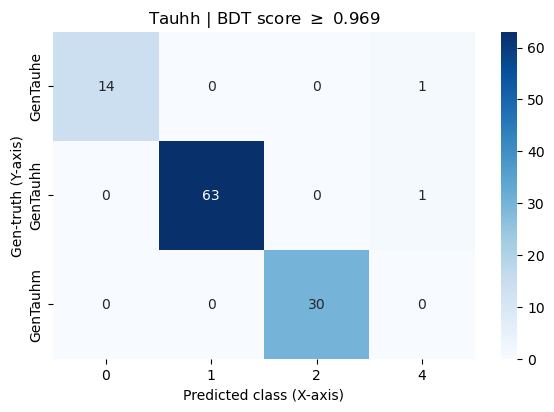

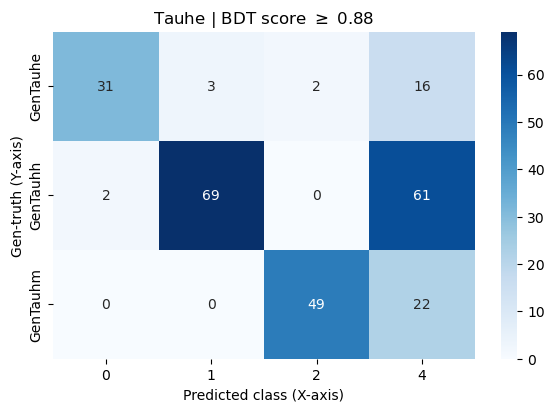

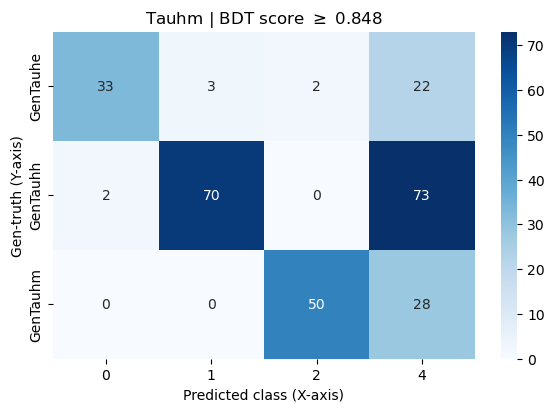

In [16]:
# Confusion martices
BDT_CUT_LUDO = {
    "Tauhh": 0.969,
    "Tauhe": 0.88,
    "Tauhm": 0.848,
}
CHANNELS = ["Tauhh", "Tauhe", "Tauhm"]
GEN_FLAGS = ["GenTauhh", "GenTauhe", "GenTauhm"]
PRED_COL  = ("bdt_best_class", 0)
SCORE_COL = ("bdt_best_score", 0)


true_labels, pred_labels = [], []

for gen_flag in GEN_FLAGS:
    mask = (df[(gen_flag, 0)] == True) & (df[SCORE_COL] >= BDT_CUT_LUDO[gen_flag.replace("Gen","")])
    preds = df.loc[mask, PRED_COL].dropna().astype(int)
    true_labels.extend([gen_flag] * len(preds))
    pred_labels.extend(preds.tolist())

# Construct DataFrame
conf_df = pd.DataFrame({"True": true_labels, "Pred": pred_labels})

cm = pd.crosstab(
    conf_df["True"], conf_df["Pred"],
    rownames=["Gen-truth (Y-axis)"], colnames=["Predicted class (X-axis)"],
    normalize=False
)

cm_norm = cm.div(cm.sum(axis=1), axis=0)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.tight_layout()
plt.show()


for ch in CHANNELS:
    score_mask =df[SCORE_COL] >= BDT_CUT_LUDO[ch]
    true_labels, pred_labels = [], []
    for gen_flag in GEN_FLAGS:
        mask = (df[(gen_flag, 0)] == True)
        mask = mask & score_mask
        preds = df.loc[mask, PRED_COL].dropna().astype(int)
        true_labels.extend([gen_flag] * len(preds))
        pred_labels.extend(preds.tolist())


    conf_df = pd.DataFrame({"True": true_labels, "Pred": pred_labels})

    cm = pd.crosstab(
        conf_df["True"], conf_df["Pred"],
        rownames=["Gen-truth (Y-axis)"], colnames=["Predicted class (X-axis)"],
        normalize=False
    )
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.tight_layout()
    plt.title(rf'{ch} | BDT score $\geq$ {BDT_CUT_LUDO[ch]}')
    plt.show()


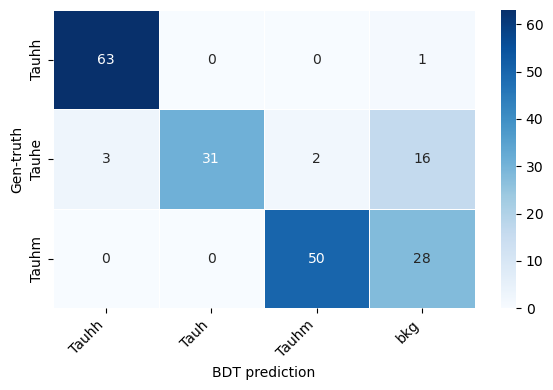

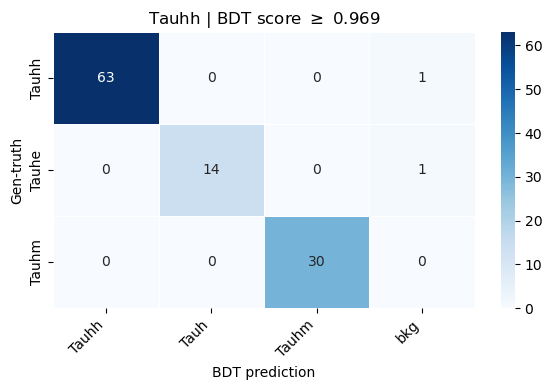

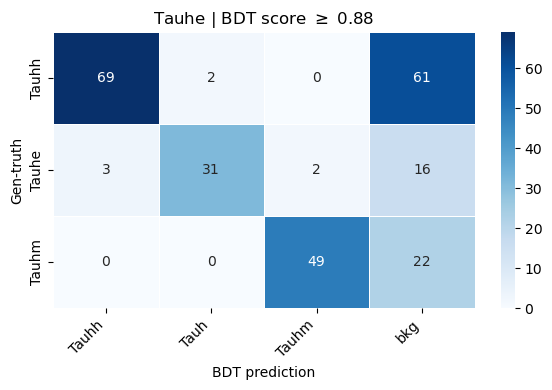

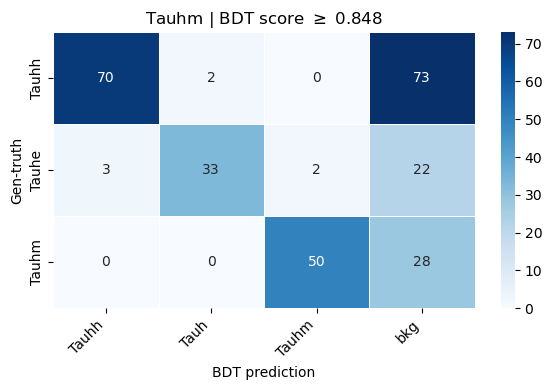

In [35]:
GEN2NAME       = {"GenTauhh": "Tauhh", "GenTauhe": "Tauhe", "GenTauhm": "Tauhm"}
PRED_IDX2NAME  = {0: "Tauhe", 1: "Tauhh", 2: "Tauhm", 4: "bkg"}  # model's class indices
DISPLAY_ALIAS  = {"Tauhe": "Tauh"}  # if you want to *display* Tauh on x-axis

ROW_ORDER = ["Tauhh", "Tauhe", "Tauhm"]        # gen truth rows (no gen-bkg)
COL_ORDER = ["Tauhh", "Tauhe", "Tauhm", "bkg"] # prediction columns

true_labels, pred_labels = [], []
for gen_flag in GEN_FLAGS:
    mask = (df[(gen_flag, 0)] == True) & (df[SCORE_COL] >= BDT_CUT_LUDO[gen_flag.replace("Gen","")])
    preds = df.loc[mask, PRED_COL].dropna().astype(int)
    true_labels.extend([gen_flag] * len(preds))
    pred_labels.extend(preds.tolist())

conf_df = pd.DataFrame({"True_raw": true_labels, "Pred_idx": pred_labels})
conf_df["True"] = conf_df["True_raw"].map(GEN2NAME)
conf_df["Pred"] = conf_df["Pred_idx"].map(PRED_IDX2NAME)

# CHANGE: Sanity checks to fail fast if an unmapped label/index appears.
# REASON: Avoid silent all-zero matrices due to NaNs.
if conf_df["True"].isna().any():
    raise ValueError(f"Unmapped truth labels: {conf_df.loc[conf_df['True'].isna(), 'True_raw'].unique()}")
if conf_df["Pred"].isna().any():
    raise ValueError(f"Unmapped prediction indices: {conf_df.loc[conf_df['Pred'].isna(), 'Pred_idx'].unique()}")

# CHANGE: Force stable row/column order and include zeros for missing classes.
# REASON: Comparable matrices even when some classes are absent.
cm = pd.crosstab(conf_df["True"], conf_df["Pred"], normalize=False)
cm = cm.reindex(index=ROW_ORDER, columns=COL_ORDER, fill_value=0)

# Optional: row-normalized version (kept for your usage)
cm_norm = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, linewidths=0.5)
ax.set_xlabel("BDT prediction")
ax.set_ylabel("Gen-truth")
# CHANGE: Display alias on x-axis (Tauhe -> Tauh) without breaking alignment.
# REASON: Cosmetic preference while keeping internal consistency.
ax.set_xticklabels([DISPLAY_ALIAS.get(c, c) for c in cm.columns], rotation=45, ha="right")
plt.tight_layout()
plt.show()

# =========================
# Per-channel confusion matrices
# =========================

for ch in CHANNELS:
    score_mask = (df[SCORE_COL] >= BDT_CUT_LUDO[ch])

    true_labels, pred_labels = [], []
    for gen_flag in GEN_FLAGS:
        mask = (df[(gen_flag, 0)] == True) & score_mask
        preds = df.loc[mask, PRED_COL].dropna().astype(int)
        true_labels.extend([gen_flag] * len(preds))
        pred_labels.extend(preds.tolist())

    conf_df = pd.DataFrame({"True_raw": true_labels, "Pred_idx": pred_labels})
    conf_df["True"] = conf_df["True_raw"].map(GEN2NAME)
    conf_df["Pred"] = conf_df["Pred_idx"].map(PRED_IDX2NAME)

    if conf_df["True"].isna().any():
        raise ValueError(f"[{ch}] Unmapped truth labels: {conf_df.loc[conf_df['True'].isna(), 'True_raw'].unique()}")
    if conf_df["Pred"].isna().any():
        raise ValueError(f"[{ch}] Unmapped prediction indices: {conf_df.loc[conf_df['Pred'].isna(), 'Pred_idx'].unique()}")

    cm = pd.crosstab(conf_df["True"], conf_df["Pred"], normalize=False)
    cm = cm.reindex(index=ROW_ORDER, columns=COL_ORDER, fill_value=0)

    plt.figure(figsize=(6, 4))
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, linewidths=0.5)
    ax.set_xlabel("BDT prediction")
    ax.set_ylabel("Gen-truth")
    ax.set_title(rf'{ch} | BDT score $\geq$ {BDT_CUT_LUDO[ch]}')
    ax.set_xticklabels([DISPLAY_ALIAS.get(c, c) for c in cm.columns], rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [ ]:
#  configuration for SR definition (BDT mode)
YEAR_STR = "2022"
PT_CUT_BB  = 250.0              # GeV
PT_CUT_TAU = 200.0              # GeV
MH_BB      = (110.0, 140.0)     # Higgs-like bb mass window

# BDT working points (bmin=5 optimum from slides)
WP = {
    "Tauhh": {"cut_bb": 0.700, "cut_tau": 0.969},
    "Tauhe": {"cut_bb": 0.841, "cut_tau": 0.822},
    "Tauhm": {"cut_bb": 0.798, "cut_tau": 0.853},
}

In [18]:
bb_pt    = gather(df, 'ak8FatJetPt',                 bb_idx)
bb_mReg  = gather(df, 'ak8FatJetParTmassResApplied', bb_idx)
tau_pt   = gather(df, 'ak8FatJetPt',                 taujet_idx)
tau_mReg = gather(df, 'ak8FatJetParTmassResApplied', taujet_idx)
xbb_bb   = gather(df, 'ak8FatJetParTXbb',            bb_idx)

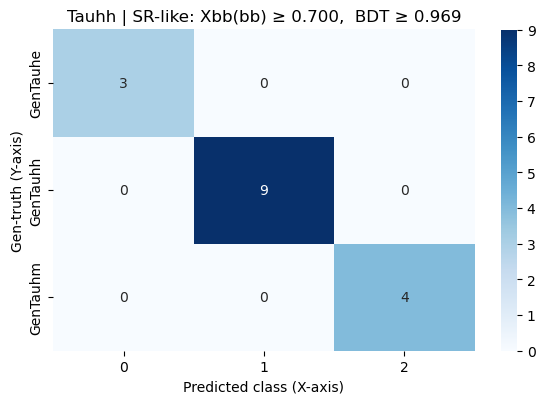

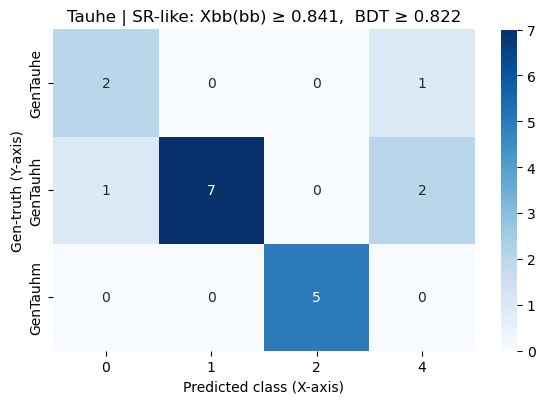

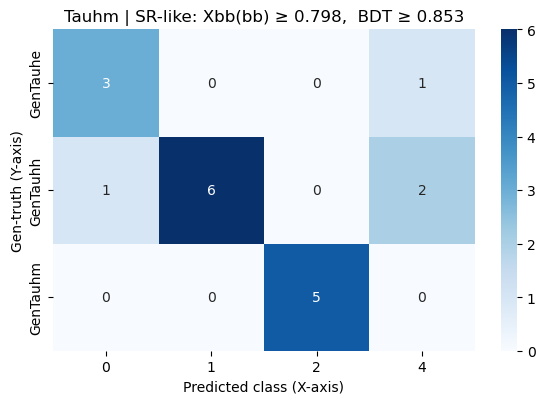

In [27]:
pt_mask = (bb_pt > PT_CUT_BB) & (tau_pt > PT_CUT_TAU)
mass_bb_mask  = (bb_mReg > MH_BB[0]) & (bb_mReg < MH_BB[1])

for ch in CHANNELS:
    cut_bb  = WP[ch]["cut_bb"]
    cut_tau = WP[ch]["cut_tau"]
    
    cut_bb_mask  = (xbb_bb >= cut_bb)
    # cut_bb_mask = (df[("bdt_best_score", 0)] >= cut_bb) # BUG: Deprecated now
    bdt_score_mask = (df[("bdt_best_score", 0)] >= cut_tau)
    
    tagger_mask = cut_bb_mask & bdt_score_mask
    
    cut_mask = pt_mask & mass_bb_mask & tagger_mask
    
    true_labels, pred_labels = [], []
    for gen_flag in GEN_FLAGS:
        mask = (df[(gen_flag, 0)] == True)
        mask = mask & cut_mask
        preds = df.loc[mask, PRED_COL].dropna().astype(int)
        true_labels.extend([gen_flag] * len(preds))
        pred_labels.extend(preds.tolist())


    conf_df = pd.DataFrame({"True": true_labels, "Pred": pred_labels})

    cm = pd.crosstab(
        conf_df["True"], conf_df["Pred"],
        rownames=["Gen-truth (Y-axis)"], colnames=["Predicted class (X-axis)"],
        normalize=False
    )
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.tight_layout()
    plt.title(rf"{ch} | SR-like: Xbb(bb) ≥ {cut_bb:.3f},  BDT ≥ {cut_tau:.3f}")
    plt.show()

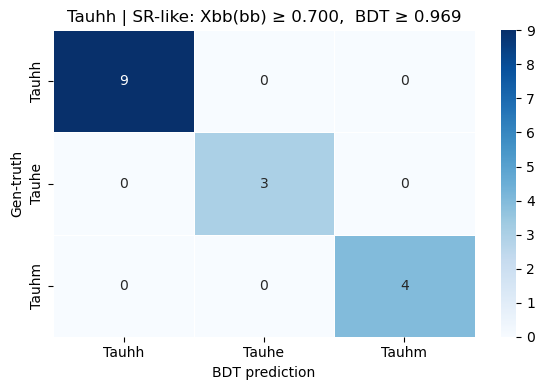

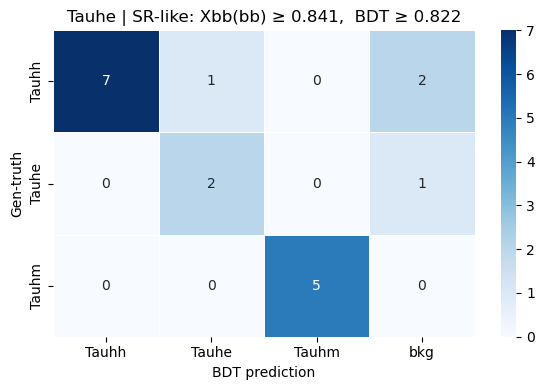

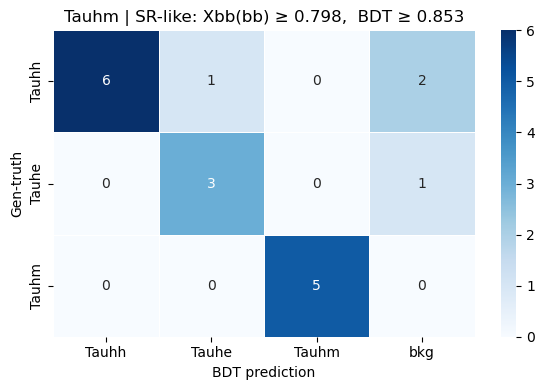

In [30]:
# CHANGE: Separate maps for gen-truth and predicted indices; add alias normalization.
# REASON: Prevent NaNs in truth labels and ensure readable axes.

GEN2NAME = {"GenTauhh": "Tauhh", "GenTauhe": "Tauhe", "GenTauhm": "Tauhm"}
PRED_IDX2NAME = {0: "Tauhe", 1: "Tauhh", 2: "Tauhm", 4: "bkg"}  # if you truly want 0→"Tauh", add alias below
ALIASES = {"Tauh": "Tauhe"}  # handle user's "Tauh" typo

row_order = ["Tauhh", "Tauhe", "Tauhm"]          # gen rows (no gen-bkg)
col_order = ["Tauhh", "Tauhe", "Tauhm", "bkg"]   # pred columns

for ch in CHANNELS:
    cut_bb  = WP[ch]["cut_bb"]
    cut_tau = WP[ch]["cut_tau"]

    cut_bb_mask   = (xbb_bb >= cut_bb)
    bdt_score_mask = (df[("bdt_best_score", 0)] >= cut_tau)
    cut_mask = pt_mask & mass_bb_mask & cut_bb_mask & bdt_score_mask

    true_labels, pred_labels = [], []
    for gen_flag in GEN_FLAGS:
        mask = (df[(gen_flag, 0)] == True) & cut_mask
        preds = df.loc[mask, PRED_COL].dropna().astype(int)
        true_labels.extend([gen_flag] * len(preds))
        pred_labels.extend(preds.tolist())

    # Build dataframe with raw fields for debugging
    conf_df = pd.DataFrame({"True_raw": true_labels, "Pred_idx": pred_labels})

    # Map to display names
    conf_df["True"] = conf_df["True_raw"].map(GEN2NAME)
    conf_df["Pred"] = conf_df["Pred_idx"].map(PRED_IDX2NAME).replace(ALIASES)

    # Quick sanity checks to catch mapping issues early
    if conf_df["True"].isna().any():
        bad = conf_df.loc[conf_df["True"].isna(), "True_raw"].unique()
        raise ValueError(f"Unmapped truth labels: {bad}")
    if conf_df["Pred"].isna().any():
        badp = conf_df.loc[conf_df["Pred"].isna(), "Pred_idx"].unique()
        raise ValueError(f"Unmapped prediction indices: {badp}")

    # Use Categorical to force stable ordering; keep only present columns if desired
    conf_df["True"] = pd.Categorical(conf_df["True"], categories=row_order, ordered=True)
    present_cols = [c for c in col_order if c in conf_df["Pred"].unique()]
    conf_df["Pred"] = pd.Categorical(conf_df["Pred"], categories=present_cols or col_order, ordered=True)

    cm = pd.crosstab(
        conf_df["True"], conf_df["Pred"],
        rownames=["Gen-truth (Y-axis)"], colnames=["BDT prediction (X-axis)"],
        normalize=False, dropna=False
    ).fillna(0).astype(int)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, linewidths=0.5)
    plt.xlabel("BDT prediction")
    plt.ylabel("Gen-truth")
    plt.title(rf"{ch} | SR-like: Xbb(bb) ≥ {cut_bb:.3f},  BDT ≥ {cut_tau:.3f}")
    plt.tight_layout()
    plt.show()


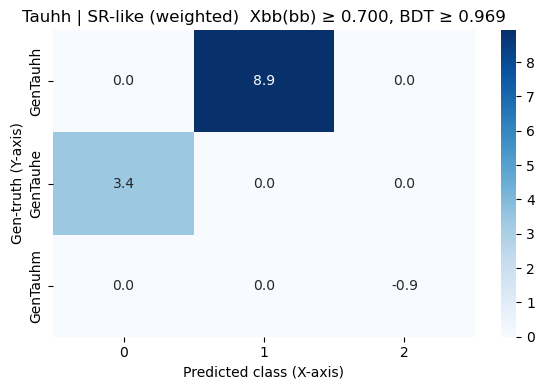

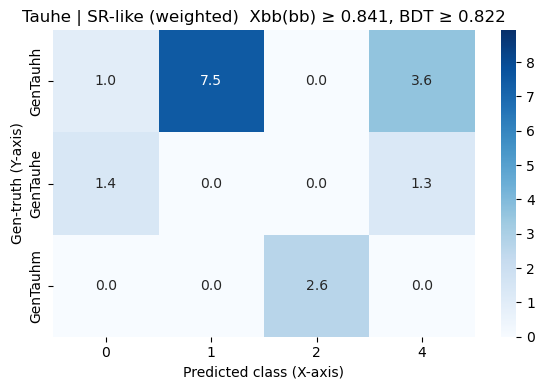

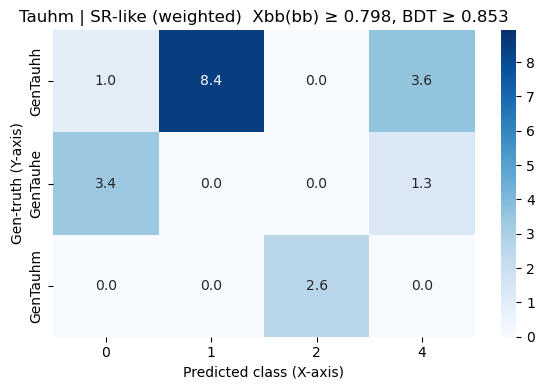

[SR Tauhh] weighted yield = 11.45
[SR Tauhe] weighted yield = 17.72
[SR Tauhm] weighted yield = 19.62


In [ ]:
def _find_weight_col(df):
    for cand in [( 'finalWeight', 0), ('weight', 0), ('genWeight', 0)]:
        if cand in df.columns:
            return cand
    raise KeyError("No weight column found (tried finalWeight/weight/genWeight).")

WEIGHT_COL = _find_weight_col(df)

def weighted_confusion_for_mask(df, GEN_FLAGS, PRED_COL, base_mask, weight_col):
    """
    Sum of weights for each (True label, Pred class) pair under base_mask.
    Returns a DataFrame indexed by True labels with Pred class columns.
    """
    parts = []
    for gen_flag in GEN_FLAGS:
        m = base_mask & (df[(gen_flag, 0)] == True)
        if not m.any():
            continue
        parts.append(pd.DataFrame({
            "True": gen_flag,
            "Pred": df.loc[m, PRED_COL].astype(int).values,
            "w":    df.loc[m, weight_col].astype(np.float64).values,
        }))
    if not parts:
        # Empty matrix with expected index ordering
        return pd.DataFrame(index=GEN_FLAGS)

    tmp = pd.concat(parts, ignore_index=True)
    cm_w = pd.pivot_table(
        tmp, values="w", index="True", columns="Pred",
        aggfunc="sum", fill_value=0.0
    )
    # Ensure all True labels are present in index (even if zero) and stable order
    cm_w = cm_w.reindex(index=GEN_FLAGS, fill_value=0.0)
    # Ensure Pred columns are sorted integers (0..n_classes-1) if desired
    cm_w = cm_w.reindex(sorted(cm_w.columns), axis=1, fill_value=0.0)
    return cm_w

weighted_mats = {}
vmax_global = 0.0  # optional: to keep a single color scale across plots

for ch in CHANNELS:
    cut_bb  = WP[ch]["cut_bb"]
    cut_tau = WP[ch]["cut_tau"]

    cut_bb_mask     = (xbb_bb >= cut_bb)
    bdt_score_mask  = (df[("bdt_best_score", 0)] >= cut_tau)
    tagger_mask     = cut_bb_mask & bdt_score_mask
    cut_mask        = pt_mask & mass_bb_mask & tagger_mask

    cm_w = weighted_confusion_for_mask(
        df=df,
        GEN_FLAGS=GEN_FLAGS,
        PRED_COL=("bdt_best_class", 0),
        base_mask=cut_mask,
        weight_col=WEIGHT_COL,
    )
    weighted_mats[ch] = cm_w
    vmax_global = max(vmax_global, float(cm_w.values.max()) if cm_w.size else 0.0)

for ch in CHANNELS:
    cm_w = weighted_mats[ch].copy()
    if cm_w.empty:
        print(f"[WARN] No events for {ch} after SR-like cuts.")
        continue

    # Absolute weighted yields
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_w, annot=True, fmt=".1f", cmap="Blues",
                vmin=0.0, vmax=vmax_global)  # keep one colorbar scale across channels
    plt.title(rf"{ch} | SR-like (weighted)  Xbb(bb) ≥ {WP[ch]['cut_bb']:.3f}, BDT ≥ {WP[ch]['cut_tau']:.3f}")
    plt.xlabel("Predicted class (X-axis)")
    plt.ylabel("Gen-truth (Y-axis)")
    plt.tight_layout()
    plt.show()

    # # Row-normalized (fractions, weighted)
    # row_sums = cm_w.sum(axis=1).replace(0.0, np.nan)
    # cm_w_norm = (cm_w.T / row_sums).T.fillna(0.0)

    # plt.figure(figsize=(6, 4))
    # sns.heatmap(cm_w_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0.0, vmax=1.0)
    # plt.title(rf"{ch} | SR-like (weighted, row-normalized)")
    # plt.xlabel("Predicted class (X-axis)")
    # plt.ylabel("Gen-truth (Y-axis)")
    # plt.tight_layout()
    # plt.show()

for ch in CHANNELS:
    cut_bb  = WP[ch]["cut_bb"]
    cut_tau = WP[ch]["cut_tau"]
    cut_bb_mask    = (xbb_bb >= cut_bb)
    bdt_score_mask = (df[("bdt_best_score", 0)] >= cut_tau)
    cut_mask = pt_mask & mass_bb_mask & cut_bb_mask & bdt_score_mask
    sr_yield_w = df.loc[cut_mask, WEIGHT_COL].astype(np.float64).sum()
    print(f"[SR {ch}] weighted yield = {sr_yield_w:.2f}")

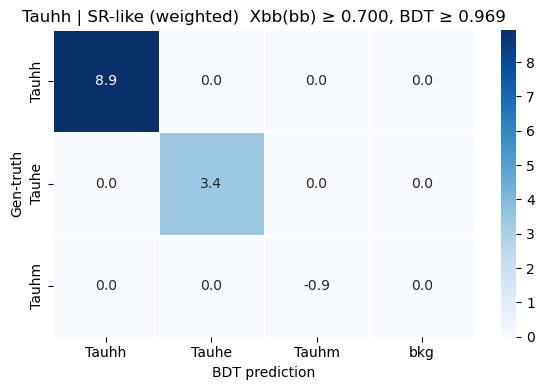

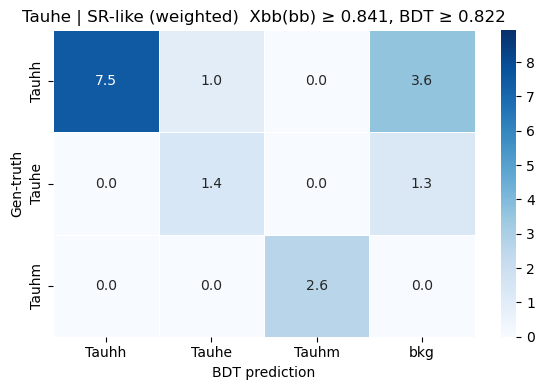

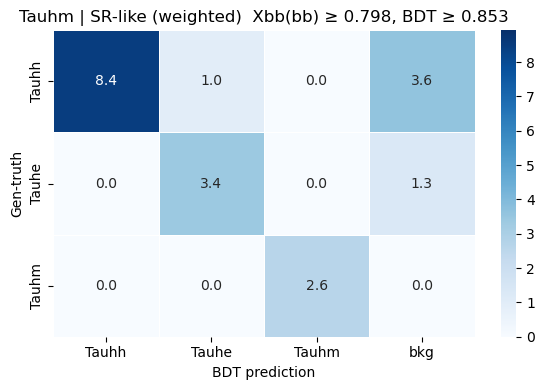

[SR Tauhh] weighted yield = 11.45
[SR Tauhe] weighted yield = 17.72
[SR Tauhm] weighted yield = 19.62


In [39]:
# CHANGE: Add explicit label maps and stable display order.
# REASON: Human-readable axes and consistent matrices even with missing classes.
GEN2NAME      = {"GenTauhh": "Tauhh", "GenTauhe": "Tauhe", "GenTauhm": "Tauhm"}
PRED_IDX2NAME = {0: "Tauhe", 1: "Tauhh", 2: "Tauhm", 4: "bkg"}  # per your mapping
ROW_ORDER     = ["Tauhh", "Tauhe", "Tauhm"]                     # gen truth rows
COL_ORDER     = ["Tauhh", "Tauhe", "Tauhm", "bkg"]               # prediction cols

def _find_weight_col(df):
    for cand in [('finalWeight', 0), ('weight', 0), ('genWeight', 0)]:
        if cand in df.columns:
            return cand
    raise KeyError("No weight column found (tried finalWeight/weight/genWeight).")

WEIGHT_COL = _find_weight_col(df)

# CHANGE: Make weighted confusion return class-name axes (not ints) and ensure ordering.
# REASON: Directly plottable heatmaps with desired labels.
def weighted_confusion_for_mask(df, GEN_FLAGS, PRED_COL, base_mask, weight_col):
    """
    Returns a DataFrame with index = gen-truth class names (Tauhh/Tauhe/Tauhm)
    and columns = predicted class names (Tauh/Tauhh/Tauhm/bkg), with values = sum of weights.
    """
    parts = []
    for gen_flag in GEN_FLAGS:
        m = base_mask & (df[(gen_flag, 0)] == True)
        if not m.any():
            continue
        # dropna before astype to avoid ValueError on NaNs
        pred_idx = df.loc[m, PRED_COL].dropna().astype(int).values
        if pred_idx.size == 0:
            continue
        w = df.loc[m, weight_col].astype(np.float64).values[:pred_idx.size]

        parts.append(pd.DataFrame({
            "True": GEN2NAME[gen_flag],               # map truth to display name
            "Pred": pd.Series(pred_idx).map(PRED_IDX2NAME).values,  # map idx->name
            "w":    w,
        }))

    if not parts:
        # Empty but with expected shape/order
        return pd.DataFrame(index=ROW_ORDER, columns=COL_ORDER, dtype=float).fillna(0.0)

    tmp = pd.concat(parts, ignore_index=True)

    # Guard against any unmapped predictions (shouldn't happen with above mapping)
    if tmp["Pred"].isna().any():
        bad = pd.unique(tmp.loc[tmp["Pred"].isna(), "Pred"])
        raise ValueError(f"Unmapped predicted classes encountered: {bad}")

    cm_w = pd.pivot_table(
        tmp, values="w", index="True", columns="Pred",
        aggfunc="sum", fill_value=0.0
    )

    # Enforce stable ordering and include missing rows/cols as zeros
    cm_w = cm_w.reindex(index=ROW_ORDER, columns=COL_ORDER, fill_value=0.0)
    cm_w = cm_w.astype(float)
    return cm_w

weighted_mats = {}
vmax_global = 0.0  # keep one colorbar scale across channels (absolute yields)

for ch in CHANNELS:
    cut_bb  = WP[ch]["cut_bb"]
    cut_tau = WP[ch]["cut_tau"]

    cut_bb_mask     = (xbb_bb >= cut_bb)
    bdt_score_mask  = (df[("bdt_best_score", 0)] >= cut_tau)
    tagger_mask     = cut_bb_mask & bdt_score_mask
    cut_mask        = pt_mask & mass_bb_mask & tagger_mask

    cm_w = weighted_confusion_for_mask(
        df=df,
        GEN_FLAGS=GEN_FLAGS,
        PRED_COL=("bdt_best_class", 0),
        base_mask=cut_mask,
        weight_col=WEIGHT_COL,
    )
    weighted_mats[ch] = cm_w
    vmax_global = max(vmax_global, float(cm_w.to_numpy().max()) if cm_w.size else 0.0)

# CHANGE: Plot absolute and (optional) row-normalized weighted matrices with fixed labels.
# REASON: Comparable scales across channels and clearer interpretation.

for ch in CHANNELS:
    cm_w = weighted_mats[ch]
    if cm_w.values.sum() == 0.0:
        print(f"[WARN] No events for {ch} after SR-like cuts.")
        continue

    # Absolute weighted yields (shared color scale)
    plt.figure(figsize=(6, 4))
    ax = sns.heatmap(cm_w, annot=True, fmt=".1f", cmap="Blues",
                     vmin=0.0, vmax=vmax_global, cbar=True, linewidths=0.5)
    ax.set_title(rf"{ch} | SR-like (weighted)  Xbb(bb) ≥ {WP[ch]['cut_bb']:.3f}, BDT ≥ {WP[ch]['cut_tau']:.3f}")
    ax.set_xlabel("BDT prediction")
    ax.set_ylabel("Gen-truth")
    plt.tight_layout()
    plt.show()

# Keep your SR yields (unchanged)
for ch in CHANNELS:
    cut_bb  = WP[ch]["cut_bb"]
    cut_tau = WP[ch]["cut_tau"]
    cut_bb_mask    = (xbb_bb >= cut_bb)
    bdt_score_mask = (df[("bdt_best_score", 0)] >= cut_tau)
    cut_mask = pt_mask & mass_bb_mask & cut_bb_mask & bdt_score_mask
    sr_yield_w = df.loc[cut_mask, WEIGHT_COL].astype(np.float64).sum()
    print(f"[SR {ch}] weighted yield = {sr_yield_w:.2f}")


In [20]:
# import json

# records = []

# for i in range(len(df)):
#     run  = int(df[('run', 0)].iloc[i])
#     lumi = int(df[('luminosityBlock', 0)].iloc[i])
#     evt  = int(df[('event', 0)].iloc[i])

#     # placeholder: channel SR flags TBD: Ask Ludo
#     # TODO: replace these with the actual final SR cuts you all agreed on,
#     # e.g. tauhh_SR = (channel=="tauhh" AND bdt > WP_tauhh AND ...).
#     tauhh_flag = bool(df[('GenTauhh', 0)].iloc[i])  # temporary proxy
#     tauhmu_flag = bool(df[('GenTauhm', 0)].iloc[i]) # temporary proxy
#     tauhe_flag  = bool(df[('GenTauhe', 0)].iloc[i]) # temporary proxy

#     # build dict of per-class BDT scores
#     # this_scores = {f"class{c}": float(yhat[i, c]) for c in range(yhat.shape[1])}

#     rec = {
#         "run": run,
#         "lumi": lumi,
#         "event": evt,
#         "year": "2022",
#         "channel_flags": {
#             "tauhh": tauhh_flag,
#             "tauhmu": tauhmu_flag,
#             "tauhe": tauhe_flag,
#         },
#         "bdt_scores": this_scores,
#         "jet_pt": float(ttFatJetPt[i]),
#         "jet_eta": float(ttFatJetEta[i]),
#         "met_pt": float(METPt[i]),
#         "weight": float(df[('weight', 0)].iloc[i]),
#     }

#     records.append(rec)

# # write to disk
# out_json_path = "overlap_payload_2022.json"
# with open(out_json_path, "w") as f:
#     for r in records:
#         f.write(json.dumps(r) + "\n")

# print("wrote", out_json_path, "with", len(records), "events")


In [21]:
# import json

# records = []

# # SR_chan_flag = "GenTauhh"
# # SR_chan_flag = "GenTauhm"
# SR_chan_flag = "GenTauhe"

# for i in range(len(df)):
#     if bool(df[(SR_chan_flag, 0)].iloc[i]):
#         run  = int(df[('run', 0)].iloc[i])
#         lumi = int(df[('luminosityBlock', 0)].iloc[i])
#         evt  = int(df[('event', 0)].iloc[i])

#         rec = {
#             "run": run,
#             "luminosityBlock": lumi,
#             "event": evt,
#             "year": "2022",
#         }

#         records.append(rec)

# # write to disk
# out_json_path = f"{SR_chan_flag}.json"
# with open(out_json_path, "w") as f:
#     for r in records:
#         f.write(json.dumps(r) + "\n")

# print("wrote", out_json_path, "with", len(records), "events")


In [41]:

def sr_mask_for_channel(ch: str) -> pd.Series:
    """Boolean mask for SR of a given channel."""
    cut_bb  = WP[ch]["cut_bb"]
    cut_tau = WP[ch]["cut_tau"]

    cut_bb_mask = (xbb_bb >= cut_bb)
    bdt_score_mask = (df[("bdt_best_score", 0)] >= cut_tau)

    m = pt_mask & mass_bb_mask & cut_bb_mask & bdt_score_mask
    return m.fillna(False)

def write_sr_json_for_channel(ch: str):
    m = sr_mask_for_channel(ch)
    cols = [( 'run', 0), ('luminosityBlock', 0), ('event', 0)]
    sel = df.loc[m, cols].dropna()

    out_list = [
        {
            "run":  int(sel[('run', 0)].iloc[i]),
            "lumi": int(sel[('luminosityBlock', 0)].iloc[i]),
            "event": int(sel[('event', 0)].iloc[i]),
            "year": str(YEAR_STR),
            "weight": float(df.loc[m, WEIGHT_COL].iloc[i]),
        }
        for i in range(len(sel))
    ]

    out_path = f"SR_{ch}.json"
    with open(out_path, "w") as f:
        json.dump(out_list, f, separators=(",", ":"))
    print(f"[SR {ch}] wrote {out_path} with {len(out_list)} events (JSON array)")
    
for ch in ["Tauhh", "Tauhe", "Tauhm"]:
    write_sr_json_for_channel(ch)

[SR Tauhh] wrote SR_Tauhh.json with 16 events (JSON array)
[SR Tauhe] wrote SR_Tauhe.json with 19 events (JSON array)
[SR Tauhm] wrote SR_Tauhm.json with 20 events (JSON array)


In [ ]:
def compute_sig_bkg_abcd(self, years, txbbcut, txttcut, mbb1, mbb2, mtt1, mtt2):
    # pass/fail from taggers
    sig_pass = 0  # resonant region pass, signal
    bg_pass_sb = 0  # sideband region pass, data
    bg_fail_res = 0  # resonant region fail, data
    bg_fail_sb = 0  # sideband region fail, data
    for year in years:
        # A
        cut_sig_pass = (
            (self.txbbs[year][self.sig_key_channel] > txbbcut)
            & (self.txtts[year][self.sig_key_channel] > txttcut)
            & (self.massbb[year][self.sig_key_channel] > mbb1)
            & (self.massbb[year][self.sig_key_channel] < mbb2)
            & (self.ptbb[year][self.sig_key_channel] > 250)
            & (self.pttt[year][self.sig_key_channel] > 200)
        )

        sig_pass += np.sum(
            self.events_dict[year][self.sig_key_channel].get_var("finalWeight")[cut_sig_pass]
        )

        for key in self.channel.data_samples:
            # B
            cut_bg_pass_sb = (
                (self.txbbs[year][key] > txbbcut)
                & (self.txtts[year][key] > txttcut)
                & (self.ptbb[year][key] > 250)
                & (self.pttt[year][key] > 200)
            )

            msb1 = (self.massbb[year][key] > SHAPE_VAR["range"][0]) & (
                self.massbb[year][key] < mbb1
            )
            msb2 = (self.massbb[year][key] > mbb2) & (
                self.massbb[year][key] < SHAPE_VAR["range"][1]
            )
            bg_pass_sb += np.sum(
                self.events_dict[year][key].get_var("finalWeight")[cut_bg_pass_sb & msb1]
            )
            bg_pass_sb += np.sum(
                self.events_dict[year][key].get_var("finalWeight")[cut_bg_pass_sb & msb2]
            )
            
            # C
            cut_bg_fail_sb = (
                ((self.txbbs[year][key] < txbbcut) | (self.txtts[year][key] < txttcut))
                & (self.ptbb[year][key] > 250)
                & (self.pttt[year][key] > 200)
            )
            bg_fail_sb += np.sum(
                self.events_dict[year][key].get_var("finalWeight")[cut_bg_fail_sb & msb1]
            )
            bg_fail_sb += np.sum(
                self.events_dict[year][key].get_var("finalWeight")[cut_bg_fail_sb & msb2]
            )
            
            # D
            cut_bg_fail_res = (
                ((self.txbbs[year][key] < txbbcut) | (self.txtts[year][key] < txttcut))
                & (self.massbb[year][key] > mbb1)
                & (self.massbb[year][key] < mbb2)
                & (self.ptbb[year][key] > 250)
                & (self.pttt[year][key] > 200)
            )

            bg_fail_res += np.sum(
                self.events_dict[year][key].get_var("finalWeight")[cut_bg_fail_res]
            )

    del cut_sig_pass, cut_bg_pass_sb, cut_bg_fail_sb, cut_bg_fail_res, msb1, msb2

    # signal=A, B, C, D, TF = C/D
    # C = bg_fail_res?
    # D = bg_fail_sb?
    
    tf = bg_fail_res / bg_fail_sb if bg_fail_sb > 0 else 0